# Inspecting the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df=pd.read_csv("Housing.csv")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB
None


In [2]:
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [3]:
cols=["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in cols:
    print(df[col].unique())

print(df["furnishingstatus"].unique())

<StringArray>
['yes', 'no']
Length: 2, dtype: str
<StringArray>
['no', 'yes']
Length: 2, dtype: str
<StringArray>
['no', 'yes']
Length: 2, dtype: str
<StringArray>
['no', 'yes']
Length: 2, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str
<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


# Mapping yes/no values to 1/0

In [4]:
for col in cols:
    df[col]=df[col].map({"yes":1, "no":0})

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

  furnishingstatus  
0        furnished  
1        furnished  
2   semi-furnished  
3        furnished  
4        furnished  


# One hot encoding furnishingstatus

In [5]:
encoded_df=pd.get_dummies(df, columns=["furnishingstatus"], dtype=int)
encoded_df=encoded_df.drop("furnishingstatus_unfurnished", axis=1) #dropping the third column to prevent repetition
print(encoded_df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_furnished  furnishingstatus_semi-furnished  
0                           1                                0  
1                           

# Graphing

## Pricing vs Area

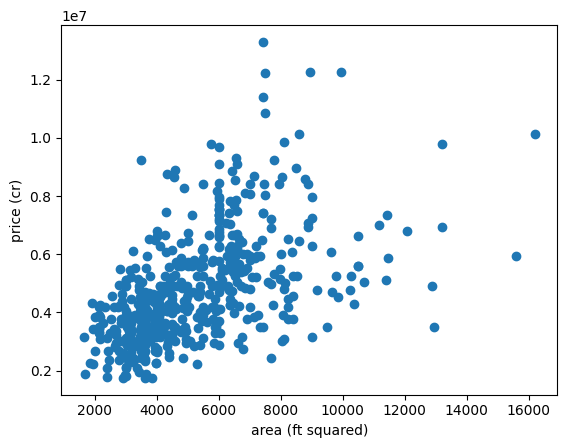

In [6]:
xpoints=np.array(df["area"])
ypoints=np.array(df["price"])
plt.scatter(xpoints, ypoints)
plt.xlabel("area (ft squared)")
plt.ylabel("price (cr)")
plt.show()

## Price Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

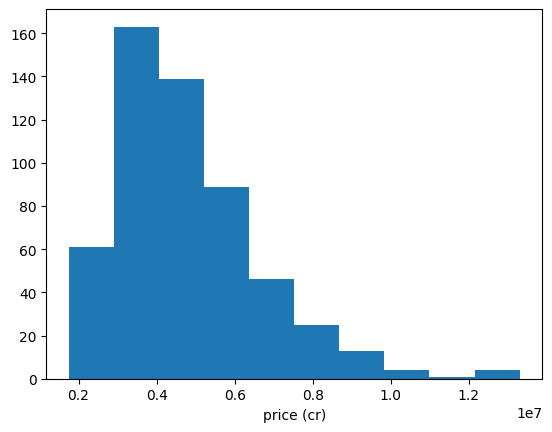

In [7]:
plt.hist(df["price"])
plt.xlabel("price (cr)")
plt.show

## Heatmap

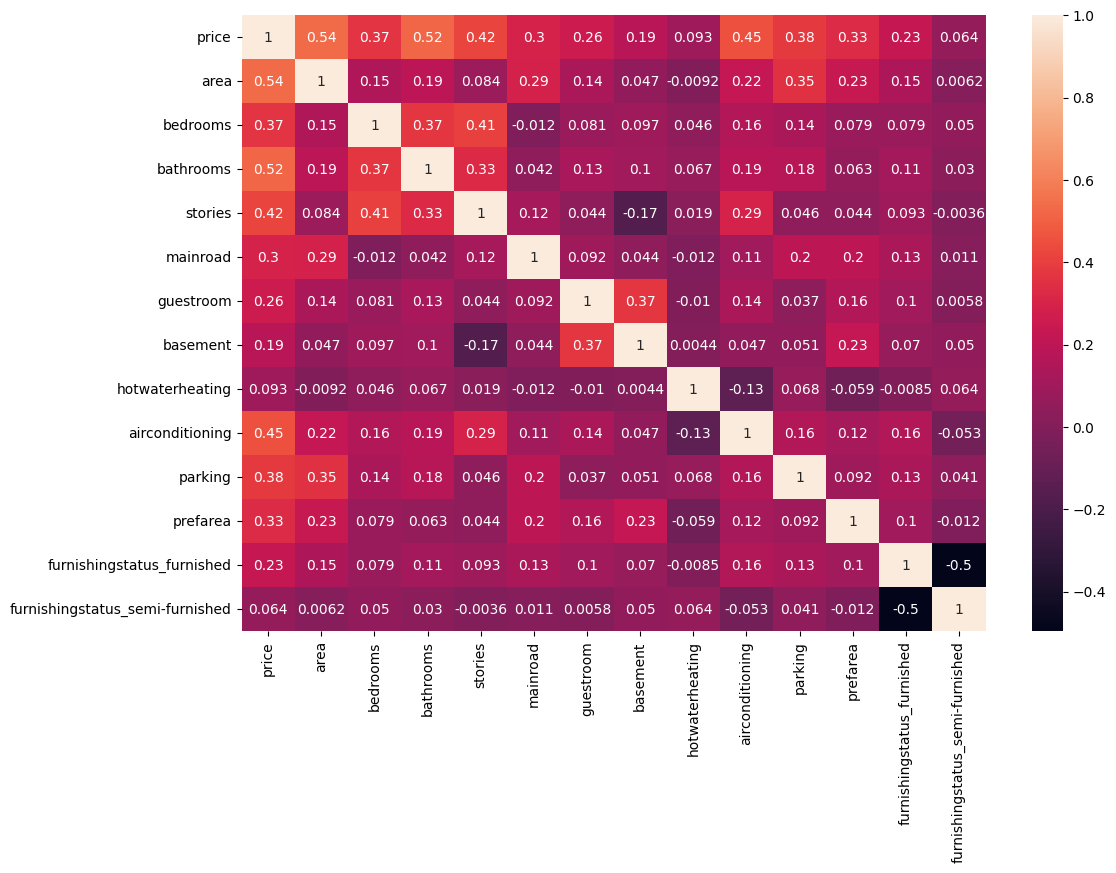

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(encoded_df.corr(), annot=True)
plt.show()

# Linear Regression

In [ ]:
def df_zscale_training(df:pd.DataFrame, columns:list): # Apply Z-Scaling to improve performance
    new_df=df.copy()
    mean={}
    std={}
    for col in columns:
        mean[col]=np.mean(df[col])
        std[col]=np.std(df[col])
        new_df[col]= (df[col]-mean[col])/std[col]
    return new_df, mean, std

def df_zscale_sample(df:pd.DataFrame, columns:list, mean:dict, std:dict): # Apply Z-Scaling to validation/testing data
    new_df=df.copy()
    for col in columns:
        new_df[col]=(df[col]-mean[col])/std[col]
    return new_df

def df_splitdata(df:pd.DataFrame): # Split the data into test, validation and train
    df = df.sample(frac=1).reset_index(drop=True) # shuffle the data
    df_length=len(df)
    training_df=df[0 : int(0.7*df_length)]
    validation_df=df[int(0.7*df_length) : int(0.8*df_length)]
    test_df=df[int(0.8*df_length) : df_length]
    return training_df, validation_df, test_df

def train_model(training_data:pd.DataFrame, target:str, epochs:int): # train the linear regression model
    y=np.array(training_data[target]) #actual values
    y=np.log(y)
    dataset=training_data.drop(columns=[target])
    w=np.zeros(len(dataset.columns)) #weights
    b=0 #bias

    # learning rates for unscaled data
    # lr_w=0.00000006
    # lr_b=0.1

    # learning rates for scaled data
    lr_w=0.5
    lr_b=0.5

    for i in range(0, epochs):
        loss=0
        dl_dw=np.zeros(len(dataset.columns))
        dl_db=0
        for j in range (0, len(dataset)):
            x=np.array(dataset.iloc[j])
            f=np.dot(x, w)+b # predicted value
            loss+=(f-y[j])**2

            for k in range (0, len(dataset.columns)): # calculate loss derivatives wrt weights
                dl_dw[k]+=(f-y[j])*x[k]
            
            dl_db+=(f-y[j])
            
        loss=loss/len(dataset)
        dl_dw=dl_dw/len(dataset)
        dl_db=dl_db/len(dataset)

        print((loss**0.5).round(6))

        for j in range (0, len(dataset.columns)): # update weights
            w[j]=w[j]-lr_w*dl_dw[j]
        b=b-lr_b*dl_db # update bias

    # print(list(w))
    return w,b

def check_model(w:np.ndarray, b:float, sample_df:pd.DataFrame, target:str): # validating/testing the model
    y=np.array(sample_df[target])
    validation_data=sample_df.drop(columns=[target])
    rmse=0
    for i in range (0, len(validation_data)):
        x=np.array(validation_data.iloc[i])
        f=np.dot(x, w)+b
        f=np.exp(f)
        rmse+=(f-y[i])**2

    rmse=(rmse/len(validation_data))**0.5
    print(rmse.round(2))

def main():
    scaling_columns=[
                    "area", 
                    "bedrooms",
                    "bathrooms",
                    "stories",
                    "parking",
                    "mainroad",
                    "guestroom",
                    "basement",
                    "hotwaterheating",
                    "airconditioning",
                    "furnishingstatus_furnished",
                    "furnishingstatus_semi-furnished"
                    ]
    
    training_df, validation_df, test_df=df_splitdata(encoded_df)

    # scale training df
    scaled_training_df, df_mean, df_std=df_zscale_training(training_df, scaling_columns)
    weights, bias = train_model(scaled_training_df, "price", 500)
    
    # scale validation df
    scaled_validation_df=df_zscale_sample(validation_df, scaling_columns, df_mean, df_std)
    print("Validated RMSE : ", end="")
    check_model(weights, bias, scaled_validation_df, "price")

    #scale test df
    scaled_test_df=df_zscale_sample(test_df, scaling_columns, df_mean, df_std)
    print("Test RMSE : ", end="")
    check_model(weights, bias, scaled_test_df, "price")

# print(f"Mean price is: {np.mean(encoded_df["price"]).round(2)}")
main()
